In [22]:
import pandas as pd
df = pd.read_csv('time_series_health_data.csv')
df

,timestamp,patient_id,temperature,heart_rate,blood_oxygen,status
0,900,V3,35.100002,67.000000,100.000000,healthy
1,930,V3,35.100002,66.847727,100.000000,healthy
2,960,V3,35.100002,67.690909,100.000000,healthy
3,990,V3,35.200001,65.550000,100.000000,healthy
4,1020,V3,35.200001,64.409091,99.000000,healthy
...,...,...,...,...,...,...
97981,11490,V6141,37.979325,95.187083,98.636872,risky
97982,11520,V6141,37.989309,96.711645,99.171999,risky
97983,11550,V6141,38.101872,97.535941,98.853465,risky
97984,11580,V6141,38.038011,99.797416,98.893792,risky



===== DATA OVERVIEW =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97986 entries, 0 to 97985
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     97986 non-null  datetime64[ns]
 1   patient_id    97986 non-null  object        
 2   temperature   97986 non-null  float64       
 3   heart_rate    97986 non-null  float64       
 4   blood_oxygen  97986 non-null  float64       
 5   status        97986 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(3), object(1)
memory usage: 3.8+ MB
None

===== FIRST ROWS =====
   timestamp patient_id  temperature  heart_rate  blood_oxygen   status
0 1970-01-01      V2768    36.447852   90.000000     99.000000  healthy
1 1970-01-01      V3612    36.455917   54.397657     98.000000  healthy
2 1970-01-01       V876    36.203311   90.116839     98.054684  healthy
3 1970-01-01      V2418    36.735625   81.000000     97.000000  

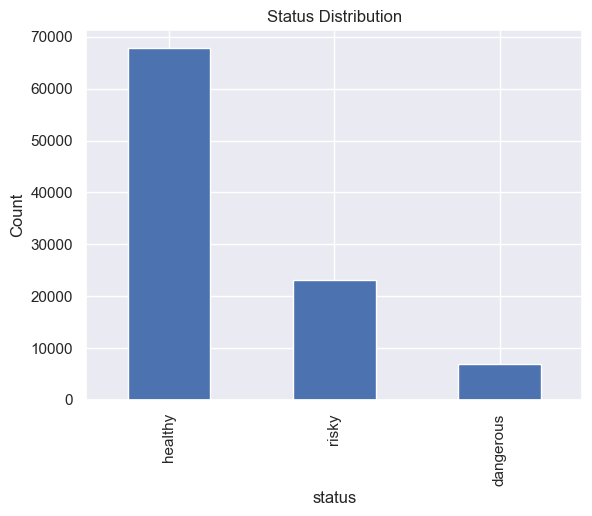


===== OUTLIER COUNT (Z > 3) =====
temperature     1807
heart_rate       910
blood_oxygen    2817
dtype: int64


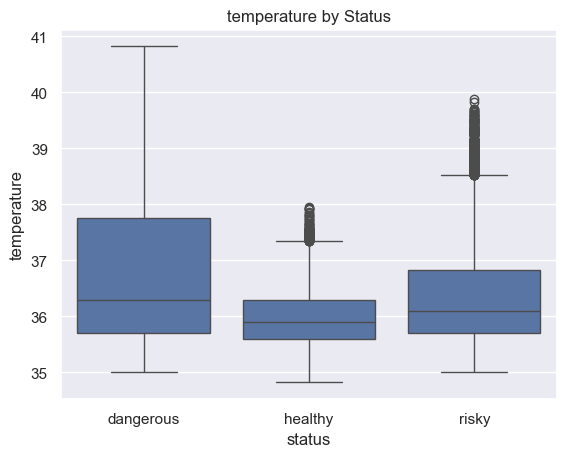

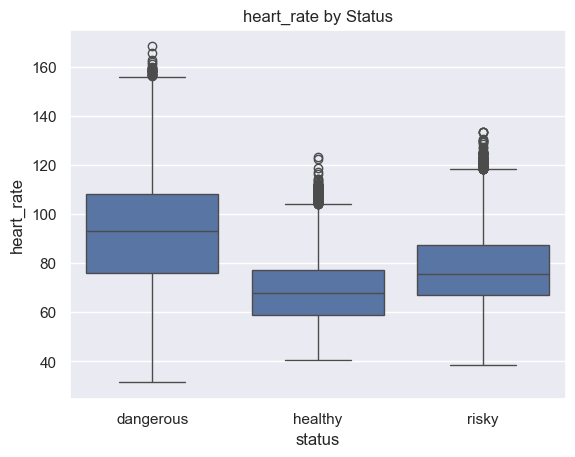

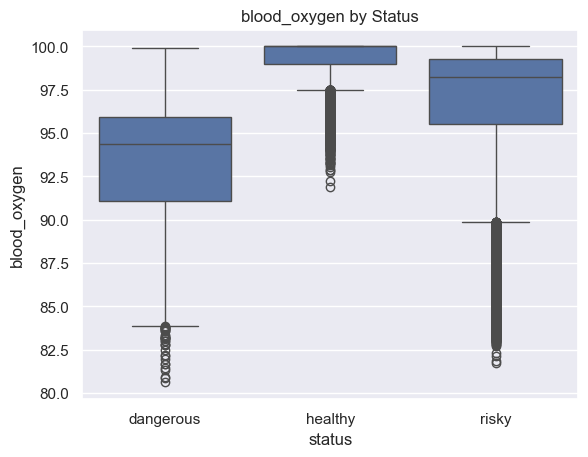


===== FINAL SUMMARY =====
Total Records: 97986
Patients: 386
Time Range: 1970-01-01 00:00:00 to 1970-01-01 07:07:30


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

# Ensure correct datatypes
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
df['patient_id'] = df['patient_id'].astype(str)
df['status'] = df['status'].astype('category')

# Sort 
df = df.sort_values("timestamp").reset_index(drop=True)

print("\n===== DATA OVERVIEW =====")
print(df.info())

print("\n===== FIRST ROWS =====")
print(df.head())

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATUS DISTRIBUTION =====")
print(df['status'].value_counts())

plt.figure()
df['status'].value_counts().plot(kind='bar')
plt.title("Status Distribution")
plt.ylabel("Count")
plt.show()

numeric_cols = ['temperature', 'heart_rate', 'blood_oxygen']

# ===============================
# 9. Outlier Detection (Z-score)
# ===============================
from scipy.stats import zscore

z_scores = np.abs(zscore(df[numeric_cols]))
outliers = (z_scores > 3)

outlier_counts = pd.DataFrame(outliers, columns=numeric_cols).sum()
print("\n===== OUTLIER COUNT (Z > 3) =====")
print(outlier_counts)

# ===============================
# 10. Relationship with Status
# ===============================
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x='status', y=col, data=df)
    plt.title(f"{col} by Status")
    plt.show()

print("\n===== FINAL SUMMARY =====")
print(f"Total Records: {len(df)}")
print(f"Patients: {df['patient_id'].nunique()}")
print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")


Healthy records: 67866
        temperature    heart_rate  blood_oxygen
count  67866.000000  67866.000000  67866.000000
mean      35.975072     68.609077     99.288361
std        0.506411     12.323463      1.079896
min       34.819846     40.662973     91.904111
25%       35.600002     59.000000     99.000000
50%       35.900002     67.809241    100.000000
75%       36.299999     77.000000    100.000000
max       37.959482    123.172698    100.000000

Correlation (healthy):
              temperature  heart_rate  blood_oxygen
temperature      1.000000    0.070581     -0.049947
heart_rate       0.070581    1.000000     -0.010681
blood_oxygen    -0.049947   -0.010681      1.000000


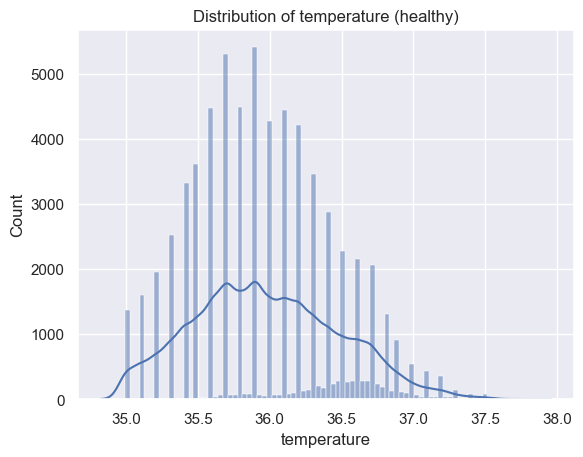

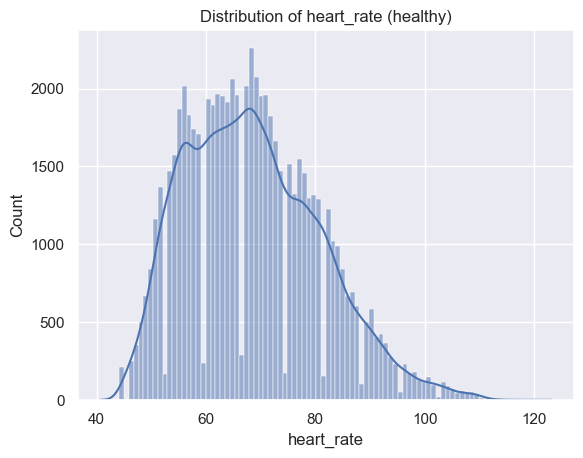

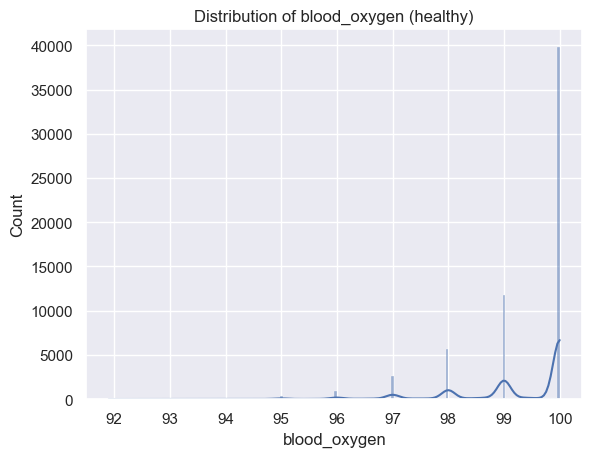

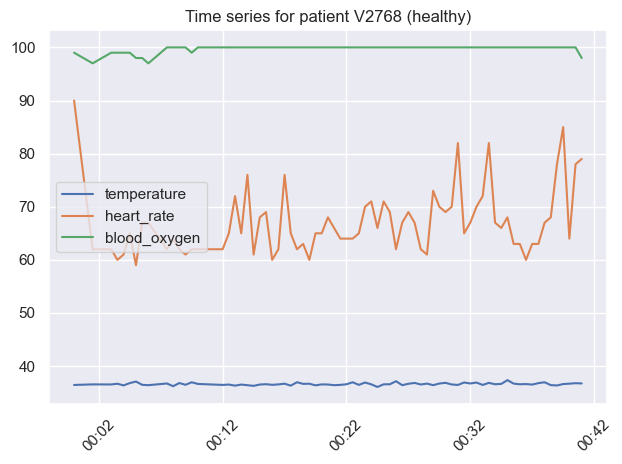

In [24]:
import matplotlib.dates as mdates

healthy = df[df['status'] == 'healthy']

print(f"Healthy records: {len(healthy)}")
print(healthy[numeric_cols].describe())

print("\nCorrelation (healthy):")
print(healthy[numeric_cols].corr())

for col in numeric_cols:
    plt.figure()
    sns.histplot(healthy[col], kde=True)
    plt.title(f"Distribution of {col} (healthy)")
    plt.xlabel(col)
    plt.show()

# example time series for a single healthy patient
sample_id = healthy['patient_id'].iloc[0]
sample = healthy[healthy['patient_id'] == sample_id]

plt.figure()
for col in numeric_cols:
    plt.plot(sample['timestamp'], sample[col], label=col)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
plt.title(f"Time series for patient {sample_id} (healthy)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_PATH = "time_series_health_data.csv"

def load_data():
    df = pd.read_csv(INPUT_PATH)
    print(f"Dataset shape: {df.shape}")
    return df


def basic_info(df):
    print("\n=== BASIC INFO ===")
    print(df.info())
    print(df.describe())


def class_distribution(df):
    print("\n=== CLASS DISTRIBUTION ===")
    dist = df['status'].value_counts(normalize=True)
    print(dist)

    dist.plot(kind='bar')
    plt.title("Class Distribution")
    plt.show()


def vital_distributions(df):
    print("\n=== VITAL DISTRIBUTIONS ===")

    cols = ['temperature', 'heart_rate', 'blood_oxygen']

    for col in cols:
        plt.figure()
        df[col].hist(bins=50)
        plt.title(f"{col} distribution")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.show()


def per_class_stats(df):
    print("\n=== PER-CLASS STATS ===")
    stats = df.groupby('status')[['temperature', 'heart_rate', 'blood_oxygen']].mean()
    print(stats)


def boxplots(df):
    cols = ['temperature', 'heart_rate', 'blood_oxygen']

    for col in cols:
        plt.figure()
        df.boxplot(column=col, by='status')
        plt.title(f"{col} by status")
        plt.suptitle("")
        plt.show()


def time_series_example(df):
    print("\n=== TIME SERIES SAMPLE ===")
    
    patient_id = df['patient_id'].sample(1).iloc[0]
    sample = df[df['patient_id'] == patient_id]

    plt.figure()
    plt.plot(sample['timestamp'], sample['heart_rate'], label='HR')
    plt.plot(sample['timestamp'], sample['blood_oxygen'], label='SpO2')
    plt.plot(sample['timestamp'], sample['temperature'], label='Temp')

    plt.legend()
    plt.title(f"Patient {patient_id}")
    plt.xlabel("Time")
    plt.show()


def correlation_analysis(df):
    print("\n=== CORRELATION ===")
    corr = df[['temperature', 'heart_rate', 'blood_oxygen']].corr()
    print(corr)

    plt.figure()
    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(3), corr.columns)
    plt.yticks(range(3), corr.columns)
    plt.title("Correlation Matrix")
    plt.show()


def anomaly_check(df):
    print("\n=== EXTREME VALUES ===")

    print("Low SpO2 < 85:")
    print(df[df['blood_oxygen'] < 85].head())

    print("High HR > 150:")
    print(df[df['heart_rate'] > 150].head())

    print("High Temp > 39:")
    print(df[df['temperature'] > 39].head())


def main():
    df = load_data()
    
    basic_info(df)
    class_distribution(df)
    vital_distributions(df)
    per_class_stats(df)
    boxplots(df)
    correlation_analysis(df)
    anomaly_check(df)
    time_series_example(df)


Dataset shape: (97986, 6)

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97986 entries, 0 to 97985
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     97986 non-null  int64  
 1   patient_id    97986 non-null  object 
 2   temperature   97986 non-null  float64
 3   heart_rate    97986 non-null  float64
 4   blood_oxygen  97986 non-null  float64
 5   status        97986 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 4.5+ MB
None
          timestamp   temperature    heart_rate  blood_oxygen
count  97986.000000  97986.000000  97986.000000  97986.000000
mean    6789.429306     36.112180     72.362218     98.324918
std     4318.662430      0.708199     15.660104      2.677244
min        0.000000     34.819846     31.366400     80.607997
25%     3360.000000     35.600002     61.000000     98.000000
50%     5880.000000     36.000000     70.000000     99.035954
7

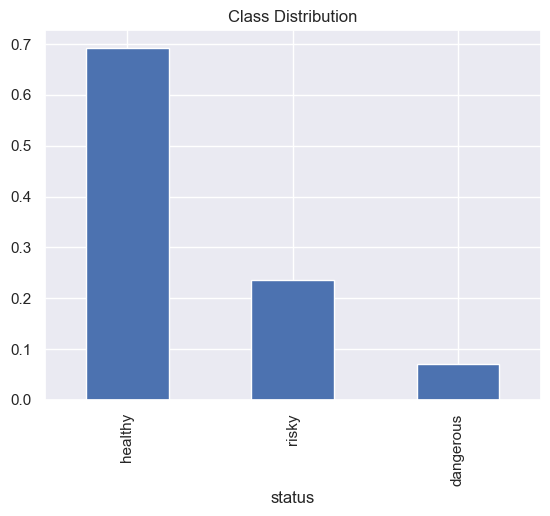


=== VITAL DISTRIBUTIONS ===


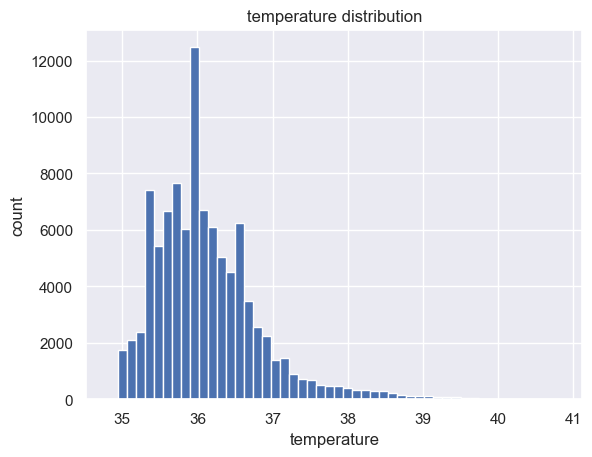

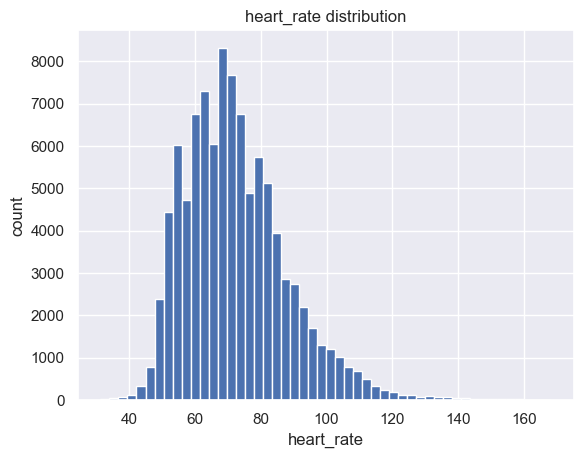

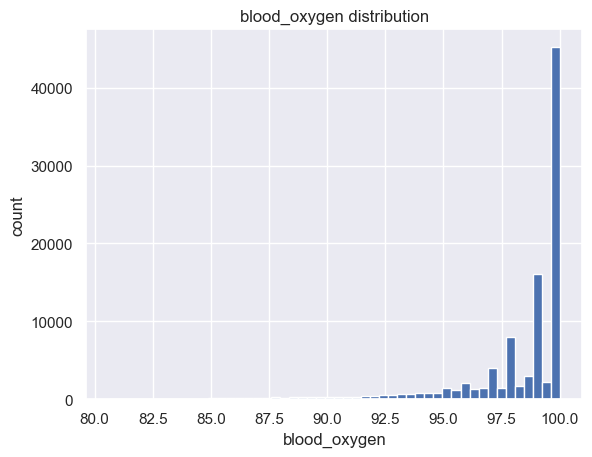


=== PER-CLASS STATS ===
           temperature  heart_rate  blood_oxygen
status                                          
dangerous    36.746432   91.345070     93.310737
healthy      35.975072   68.609077     99.288361
risky        36.323822   77.670749     97.004437


<Figure size 640x480 with 0 Axes>

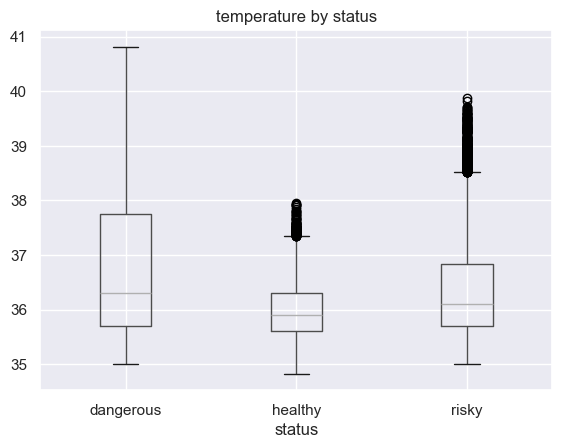

<Figure size 640x480 with 0 Axes>

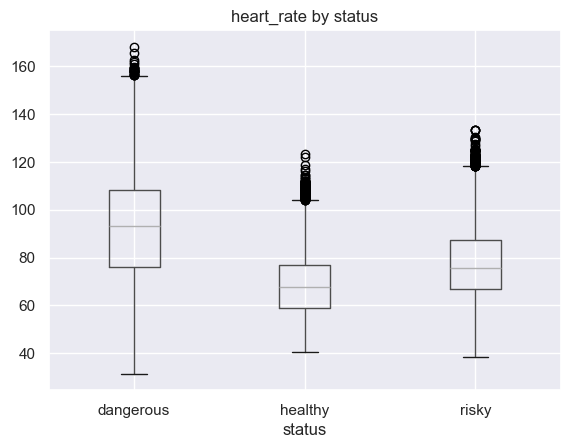

<Figure size 640x480 with 0 Axes>

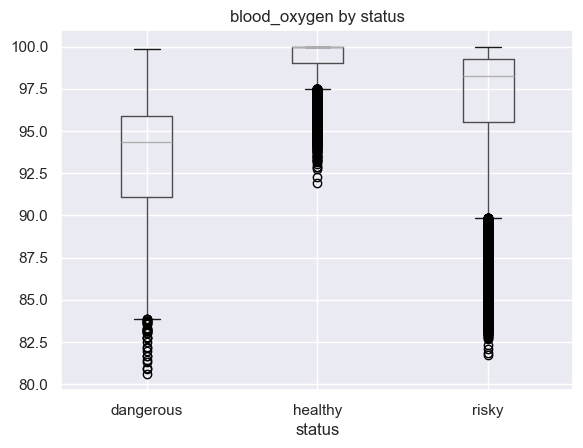


=== CORRELATION ===
              temperature  heart_rate  blood_oxygen
temperature      1.000000    0.331803     -0.249139
heart_rate       0.331803    1.000000     -0.390226
blood_oxygen    -0.249139   -0.390226      1.000000


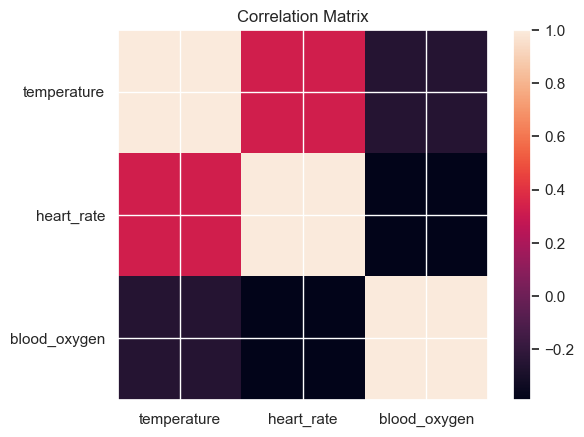


=== EXTREME VALUES ===
Low SpO2 < 85:
      timestamp patient_id  temperature  heart_rate  blood_oxygen     status
2925       5160       V121    37.726598   93.445524     84.751828  dangerous
2926       5190       V121    37.676943   93.012395     84.904754  dangerous
2928       5250       V121    37.775884   93.173665     84.900452  dangerous
2946       5790       V121    38.130206   97.270726     84.333247  dangerous
3055       3810       V159    35.900002   89.059979     84.945186      risky
High HR > 150:
      timestamp patient_id  temperature  heart_rate  blood_oxygen     status
5425       6060       V387    39.014066  154.948542     84.179854  dangerous
5427       6270       V387    39.138980  153.040056     84.745624  dangerous
5428       6300       V387    39.271552  153.884598     83.572482  dangerous
5429       6330       V387    39.285978  153.786251     84.219846  dangerous
5430       6360       V387    39.403909  153.224818     81.692367  dangerous
High Temp > 39:
      

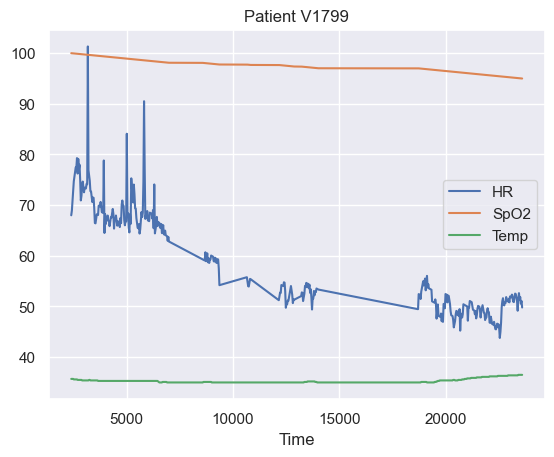

In [26]:
main()

In [27]:
print(df['status'].value_counts(normalize=True))

status
healthy      0.692609
risky        0.236626
dangerous    0.070765
Name: proportion, dtype: float64
